In [9]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

modelo = joblib.load("../models/model.pkl")          
vectorizer = joblib.load("../models/vectorizer.pkl")

df = pd.read_csv("../data/processed/dados_limpos.csv")

df.head()


,Search Query,Product Title,Link,Review,Sentiment
0,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,Com a necessidade de comprar um celular custo ...,positivo
1,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,Minha experiência de 10 dias de uso com o Xiao...,positivo
2,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,"Smartphone de qualidade como já esperava, boas...",positivo
3,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,atendeu mto minhas expectativas. Antes eu usa...,positivo
4,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,"Gostei muito do celular, tem resposta rápida e...",positivo


In [10]:
X = df["Review"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


Acuracia: 0.4956698930208864

Relatório de Classificação: 

              precision    recall  f1-score   support

    negativo       0.00      0.00      0.00      1963
    positivo       0.50      0.99      0.66      1963

    accuracy                           0.50      3926
   macro avg       0.25      0.50      0.33      3926
weighted avg       0.25      0.50      0.33      3926



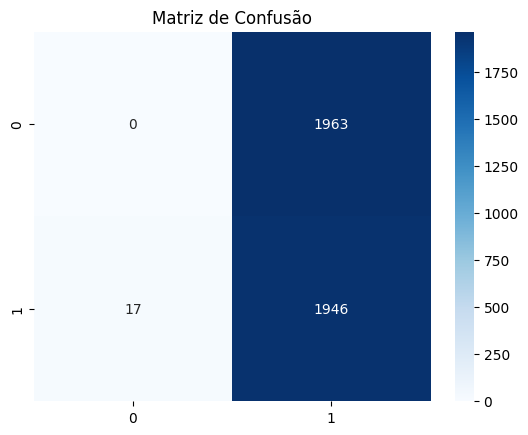

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = modelo.predict(X_test_vec)

print("Acuracia:", accuracy_score(y_test, preds))
print("\nRelatório de Classificação: \n")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Matriz de Confusão")
plt.show()
